### Coupling GIPL and ECSimpleSnow models

Before you begin, install:

```conda install -c conda-forge pymt pymt_gipl pymt_ecsimplesnow seaborn```

In [41]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import pymt.models

sns.set(style="whitegrid", font_scale=1.2)

#### Load ECSimpleSnow module from PyMT

In [42]:
ec = pymt.models.ECSimpleSnow()
print(ec.name)

# List input and output variable names3
print(ec.output_var_names)
print(ec.input_var_names)

The 1D Snow Model
('snowpack__depth', 'snowpack__mass-per-volume_density')
('precipitation_mass_flux', 'land_surface_air__temperature', 'precipitation_mass_flux_adjust_factor', 'snow_class', 'open_area_or_not', 'snowpack__initial_depth', 'snowpack__initial_mass-per-volume_density')


#### Load GIPL module from PyMT

In [43]:
gipl = pymt.models.GIPL()
print(gipl.name)

# List input and output variable names.
print(gipl.output_var_names)
print(gipl.input_var_names)

The 1D GIPL Model
('soil__temperature', 'model_soil_layer__count')
('land_surface_air__temperature', 'snowpack__depth', 'snow__thermal_conductivity', 'soil_water__volume_fraction', 'soil_unfrozen_water__a', 'soil_unfrozen_water__b')


Call the setup method on both ECSimpleSnow and GIPL to get default configuration files and data.

In [44]:
ec_defaults = ec.setup(".")
print(ec_defaults)

gipl_defaults = gipl.setup(".")
print(gipl_defaults)

('snow_model.cfg', '/home/Documents/University/bmi-compose/test')
('gipl_config.cfg', '/home/Documents/University/bmi-compose/test')


In [45]:
ec.initialize("snow_model.cfg")

 *** Warning: No available path, will try to find inputs
 from the same folder of this configuration :
 ./                                                              


In [46]:
gipl.initialize("gipl_config.cfg")

 *** Warning: No available path, will try to find inputs
 from the same folder of this configuration :
 ./                                                                                                                                                                  
 *** Warning: No available output path, will try to write outputs
 to the same folder of this configuration :
 ./                                                                                                                                                                  


In [47]:
# Get soil depth: [unit: m]
depth = gipl.get_grid_z(2)
n_depth = int(len(depth))

/tmp/ipykernel_1832/1631582154.py:2: DeprecationWarning: Call to deprecated method get_grid_z. (use grid_z)
  depth = gipl.get_grid_z(2)


In [48]:
# Get the length of forcing data:
ntime = int(gipl.end_time)

# Define a variable to store soil temperature through the time period

tsoil = np.zeros((n_depth, ntime)) * np.nan

print("Final soil temperatures will be ", tsoil.shape)

Final soil temperatures will be  (176, 365)


[ 6.388889    6.388792    6.3886957   6.3886      6.388505    6.3884106
  6.388317    6.388224    6.388132    6.3880405   6.3879495   6.3878593
  6.3877697   6.387681    6.387593    6.3875055   6.3874187   6.3873324
  6.387247    6.387162    6.387078    6.3869944   6.386912    6.3868294
  6.3867483   6.3866673   6.386587    6.386508    6.3864293   6.386398
  6.386367    6.3863354   6.38632     6.3863044   6.386289    6.3862815
  6.3862767   6.3862753   6.386274    6.371599    6.3569303   6.312961
  6.239798    6.0939097   5.948576    5.803768    5.6594577   5.2293477
  4.944555    4.6611204   4.3788586   4.097601    3.817196    3.5375135
  3.1766462   2.816614    2.4572823   2.0985749   1.7404675   1.3829821
  1.0261757   0.6701272   0.43175682  0.19398053 -0.04318963 -0.17141826
 -0.27011058 -0.3566053  -0.43578595 -0.5099031  -0.58022666 -0.64755946
 -0.7124476  -0.7752818  -0.8363527  -0.8958829  -0.9540466  -1.0109831
 -1.0668055  -1.1216066  -1.1754638  -1.2284424  -1.2805977  -1.

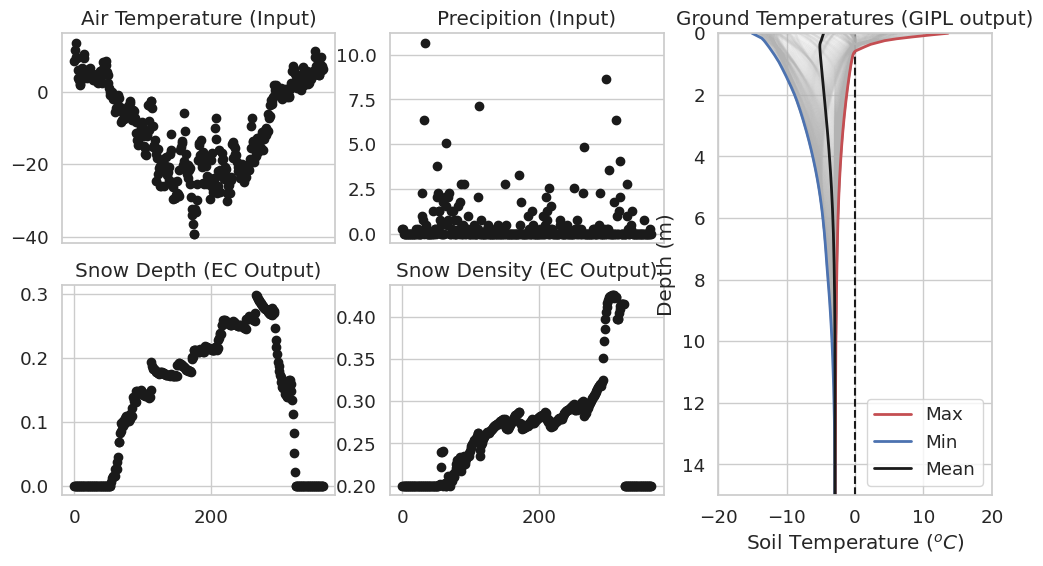

In [49]:
fig = plt.figure(figsize=[12, 6])

ax2 = fig.add_subplot(2, 3, 1)
ax2.set_title("Air Temperature (Input)")

ax3 = fig.add_subplot(2, 3, 2)
ax3.set_title("Precipition (Input)")

ax4 = fig.add_subplot(2, 3, 4)
ax4.set_title("Snow Depth (EC Output)")

ax5 = fig.add_subplot(2, 3, 5)
ax5.set_title("Snow Density (EC Output)")

ax1 = fig.add_subplot(2, 3, (3, 6))
ax1.set_ylim([15, 0])
ax1.set_xlim([-20, 20])
ax1.set_xlabel("Soil Temperature ($^oC$)")
ax1.set_ylabel("Depth (m)")
ax1.plot([0, 0], [15, 0], "k--")

for i in np.arange(365):

    ec.update()  # Update Snow Model Once

    # Get output from snow model
    tair = ec.get_value("land_surface_air__temperature")
    prec = ec.get_value("precipitation_mass_flux")
    snd = ec.get_value("snowpack__depth", units="m")
    rsn = ec.get_value("snowpack__mass-per-volume_density", units="g cm-3")

    # Pass value to GIPL model
    gipl.set_value("land_surface_air__temperature", tair)
    gipl.set_value("snowpack__depth", snd)
    gipl.set_value("snow__thermal_conductivity", rsn * rsn * 2.846)

    gipl.update()  # Update GIPL model Once

    tsoil[:, i] = gipl.get_value("soil__temperature")  # Save results to a matrix

    ax1.plot(tsoil[depth >= 0, i], depth[depth >= 0], color=[0.7, 0.7, 0.7], alpha=0.1)

    ax2.scatter(i, tair, c="k")
    ax3.scatter(i, prec, c="k")
    ax4.scatter(i, snd, c="k")
    ax5.scatter(i, rsn, c="k")

ax1.plot(
    tsoil[depth >= 0, :].max(axis=1), depth[depth >= 0], "r", linewidth=2, label="Max"
)
ax1.plot(
    tsoil[depth >= 0, :].min(axis=1), depth[depth >= 0], "b", linewidth=2, label="Min"
)
ax1.plot(
    tsoil[depth >= 0, :].mean(axis=1), depth[depth >= 0], "k", linewidth=2, label="Mean"
)
ax1.legend()
ax1.set_title("Ground Temperatures (GIPL output)")

ax2.set_xticks([])
ax3.set_xticks([])

print(gipl.get_value("soil__temperature") )

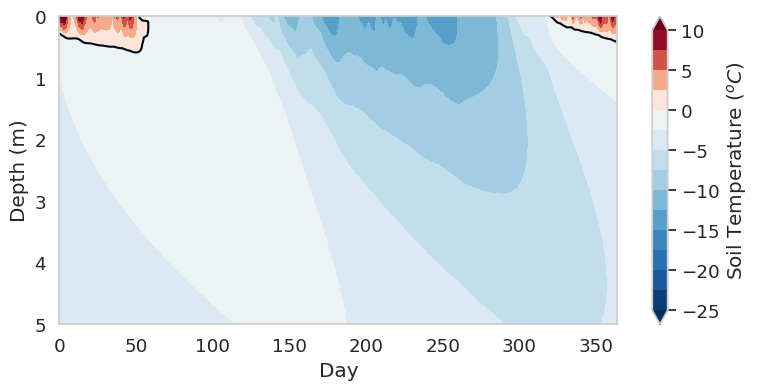

In [50]:
fig = plt.figure(figsize=[9, 4])
divnorm = mcolors.TwoSlopeNorm(vmin=-25.0, vcenter=0.0, vmax=10)
plt.contourf(
    np.arange(ntime),
    depth,
    tsoil,
    np.linspace(-25, 10, 15),
    norm=divnorm,
    cmap="RdBu_r",
    extend="both",
)

plt.ylim([5, 0])
cb = plt.colorbar()
plt.xlabel("Day")
plt.ylabel("Depth (m)")
cb.ax.set_ylabel("Soil Temperature ($^oC$)")

plt.contour(np.arange(ntime), depth, tsoil, [0])  # ZERO